In [51]:
# PySCF, Vayesta and Dyson imports 
from pyscf import fci, gto, scf, ao2mo
from vayesta.lattmod import Hubbard1D, LatticeRHF
from dyson import MBLGF, MixedMBLGF, FCI, Lehmann, util, NullLogger
from dyson.util import greens_function_galitskii_migdal

# General and Qesm imports
import numpy as np
# from qesm.aer_recursive import *
# from qesm.aer_direct import *
# from qesm.aer_rdm import *
# from qesm.aer_util import primatives
from matplotlib import pyplot as plt


In [62]:
mol = gto.Mole(
    atom = 'H 0 0 0; Li 0 0 1.6', 
    basis = 'sto-3g', # minimal basis set
    spin = 0 # singlet state
)

# perform Hartree-Fock calculation
mf = scf.RHF(mol)
mf.kernel() 

myci = fci.FCI(mf, mf.mo_coeff)

#fci observables
fci_energy , fci_vecs = myci.kernel()
fci_1rdm = myci.make_rdm1(fci_vecs, mf.mo_coeff.shape[1],mol.nelec)
fci_2rdm = myci.make_rdm2(fci_vecs, mf.mo_coeff.shape[1],mol.nelec)

###################### FCI spectral function ###################### 
nmom = 5

expr = FCI["1h"](mf, mo_energy=mf.mo_energy, mo_coeff=mf.mo_coeff, mo_occ=mf.mo_occ)
th_fci = expr.build_gf_moments(nmom+1)

expr = FCI["1p"](mf, mo_energy=mf.mo_energy, mo_coeff=mf.mo_coeff, mo_occ=mf.mo_occ)
tp_fci = expr.build_gf_moments(nmom+1)

solverh = MBLGF(th_fci, log=NullLogger())
solverp = MBLGF(tp_fci, log=NullLogger())
solver = MixedMBLGF(solverh, solverp)
solver.kernel()
E,V = solver.get_dyson_orbitals()
grid = np.linspace(-5, 5, 1000)

sf_fci = util.build_spectral_function(E, V, grid, eta=0.05)
#########################################################

converged SCF energy = -7.86186476980865


Initialize <pyscf.gto.mole.Mole object at 0x126a1f740> in <pyscf.scf.hf.RHF object at 0x126a0fa40>


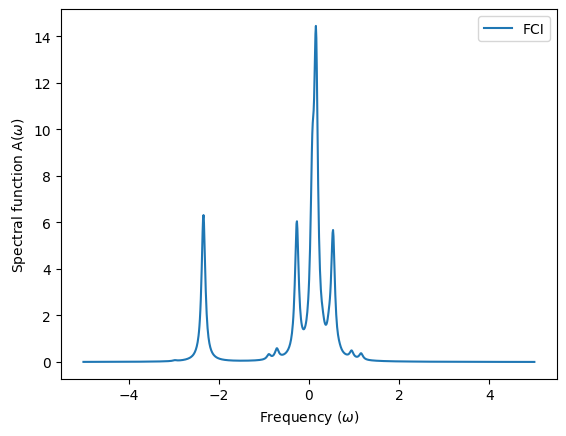

In [63]:
plt.plot(grid,sf_fci,'-',label='FCI')
plt.xlabel("Frequency ($\omega$)")
plt.ylabel("Spectral function A($\omega$)")
plt.legend()
plt.show()

In [64]:
th_fci

array([[[ 9.99954173e-01, -1.39152163e-04,  2.19930500e-04, -1.80650968e-18, -6.93973315e-19, -6.44077290e-04],
        [-1.39152163e-04,  9.75712996e-01,  3.70197645e-02, -2.57525054e-17, -9.54810764e-18,  5.52155379e-03],
        [ 2.19930500e-04,  3.70197645e-02,  6.26014170e-03,  2.23557307e-19,  5.97958514e-20, -8.71176678e-03],
        [-1.80650968e-18, -2.57525054e-17,  2.23557307e-19,  7.59078980e-04,  3.03067684e-30, -1.84874202e-18],
        [-6.93973315e-19, -9.54810764e-18,  5.97958514e-20,  3.03067684e-30,  7.59078980e-04, -6.56849264e-19],
        [-6.44077290e-04,  5.52155379e-03, -8.71176678e-03, -1.84874202e-18, -6.56849264e-19,  1.65545314e-02]],

       [[-2.34895643e+00,  1.85479530e-04,  4.01775803e-04,  4.45750609e-18,  1.78968623e-18,  7.03301959e-04],
        [ 1.85479530e-04, -3.01562530e-01, -1.98651900e-03,  1.14812046e-17,  4.22951268e-18, -1.92396061e-02],
        [ 4.01775803e-04, -1.98651900e-03, -3.40918801e-03, -6.13118735e-19, -2.19106545e-19,  6.02238

In [65]:
print(2*np.array(th_fci))

[[[ 1.99990835e+00 -2.78304326e-04  4.39860999e-04 -3.61301937e-18 -1.38794663e-18 -1.28815458e-03]
  [-2.78304326e-04  1.95142599e+00  7.40395290e-02 -5.15050108e-17 -1.90962153e-17  1.10431076e-02]
  [ 4.39860999e-04  7.40395290e-02  1.25202834e-02  4.47114613e-19  1.19591703e-19 -1.74235336e-02]
  [-3.61301937e-18 -5.15050108e-17  4.47114613e-19  1.51815796e-03  6.06135368e-30 -3.69748404e-18]
  [-1.38794663e-18 -1.90962153e-17  1.19591703e-19  6.06135368e-30  1.51815796e-03 -1.31369853e-18]
  [-1.28815458e-03  1.10431076e-02 -1.74235336e-02 -3.69748404e-18 -1.31369853e-18  3.31090628e-02]]

 [[-4.69791286e+00  3.70959061e-04  8.03551605e-04  8.91501219e-18  3.57937246e-18  1.40660392e-03]
  [ 3.70959061e-04 -6.03125060e-01 -3.97303800e-03  2.29624093e-17  8.45902536e-18 -3.84792123e-02]
  [ 8.03551605e-04 -3.97303800e-03 -6.81837601e-03 -1.22623747e-18 -4.38213090e-19  1.20447707e-02]
  [ 8.91501219e-18  2.29624093e-17 -1.22623747e-18 -1.21354261e-03 -2.60914795e-29  3.23010801e-18

In [56]:
def galitskii_migdal_energy(one_mo, hole_moments, nuclear_repulsion_energy=0.0):
    """
    Galitskii-Migdal energy from spin-summed MO-basis hole moments.

    For RHF/spin-summed moments:

        E_elec = 1/2 [ Tr(T_h^(0) h) + Tr(T_h^(1)) ]

    """

    hole_moments = np.asarray(hole_moments, dtype=complex)

    if hole_moments.shape[0] < 2:
        raise ValueError("Need hole moments up to first order.")

    T0_hole = hole_moments[0]
    T1_hole = hole_moments[1]

    E_elec = (
        np.einsum("ij,ji->", T0_hole, one_mo)
        + np.trace(T1_hole)
    ).real

    return {
        "electronic": E_elec,
        "total": E_elec + nuclear_repulsion_energy,
    }

In [57]:
one_ao = mf.get_hcore()
two_ao = mol.intor("int2e_sph")

one_mo = np.einsum("pi,pq,qj->ij", mf.mo_coeff, one_ao, mf.mo_coeff)

two_mo = ao2mo.incore.full(two_ao, mf.mo_coeff)
two_mo = np.swapaxes(two_mo, 1, 3)

gm_energy = galitskii_migdal_energy(one_mo, th_fci, nuclear_repulsion_energy=mol.energy_nuc())
print("Galitskii-Migdal energy: ", gm_energy)
print("FCI energy: ", fci_energy)

Galitskii-Migdal energy:  {'electronic': np.float64(-2.241563433868436), 'total': np.float64(-1.2966041286541503)}
FCI energy:  -1.4963558778980217
